# §8 Manufacturer concentration

How concentrated is the hardware science runs on, and is anything eroding it?

* **8.1 Manufacturer shares** over time, by field.
* **8.2 Concentration indices** — HHI and entropy across manufacturers.
* **8.3 CUDA lock-in proxy** — share of accelerator papers whose passages
  mention CUDA vs the portable alternatives (OpenCL/ROCm/SYCL/oneAPI). Software
  lock-in is the mechanism that would keep concentration sticky even if rival
  silicon becomes competitive.
* **8.4 Multi-vendor papers** — do papers ever mix vendors?
* **8.5 Export-control sidebar** — A800/H800/H20, the China-market parts created
  by the 2022/2023 US controls. Their appearance is a natural experiment in how
  fast policy reaches the bench.

**Denominator discipline.** Shares are over papers that name a *specific model*
and report *using* it, so generic "we used a GPU" papers (which carry no
manufacturer information) cannot inflate any vendor. The share of accelerator
papers that are generic-only is plotted first, since a falling unknown share can
mechanically manufacture apparent growth.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from accelscan.config import BUCKET, OUT_PREFIX
from accelscan.normalize import canonicalize_column
from accelscan.registry import load_registry
from accelscan.s3 import mentions_glob, storage_options
from accelscan.plotting import setup_figures

# integer year ticks + every figure exported to output/analysis/manufacturer/
setup_figures('manufacturer')

## Knobs

In [2]:
MODEL_TAG, PROMPT_VERSION = 'qwen3-14b', 'p1'
YEAR_MIN, YEAR_MAX = 2005, 2025
MIN_PAPERS = 100
LOCAL_ANALYTIC = None
VENDORS = ['nvidia', 'amd', 'intel', 'google', 'apple', 'huawei', 'graphcore',
           'cerebras', 'amazon']
VC = {'nvidia': '#76B900', 'amd': '#ED1C24', 'intel': '#0071C5', 'google': '#F9AB00',
      'apple': '#A2AAAD', 'huawei': '#CF0A2C', 'graphcore': '#FF6F61',
      'cerebras': '#6A4C93', 'amazon': '#FF9900'}
reg = load_registry(); so = storage_options()

## Load model-specific used mentions

In [3]:
base = (LOCAL_ANALYTIC or
        f's3://{BUCKET}/{OUT_PREFIX}/analytic/{reg.version}/{PROMPT_VERSION}/{MODEL_TAG}')
rd = (lambda n: pl.read_parquet(f'{base}/{n}.parquet')) if LOCAL_ANALYTIC else \
     (lambda n: pl.read_parquet(f'{base}/{n}.parquet', storage_options=so))
den = rd('denominator').select('corpusid', 'year', 'field')
flags = rd('paper_flags')

m = (pl.scan_parquet(mentions_glob(MODEL_TAG, PROMPT_VERSION), storage_options=so)
     .filter(pl.col('status') == 'ok')
     .select('corpusid', 'model_normalized', 'manufacturer', 'usage_context')
     .collect())
mu = m.filter(pl.col('usage_context') == 'used-in-this-work')
mu = canonicalize_column(mu, reg)

# registry manufacturer is authoritative for canonicalized models; fall back to LLM label
regman = {x.id: x.manufacturer for x in reg.models.values()}
spec = (mu.filter(pl.col('canonical_kind') == 'model')
        .with_columns(vendor=pl.coalesce(
            pl.col('canonical_model').replace_strict(regman, default=None),
            pl.col('manufacturer')))
        .filter(pl.col('vendor').is_in(VENDORS))
        .select('corpusid', 'vendor', 'canonical_model').unique()
        .join(den, on='corpusid', how='inner')
        .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX)))
print(f'{spec.height:,} paper-vendor observations | {spec.n_unique("corpusid"):,} papers '
      f'naming a specific used model')

197,376 paper-vendor observations | 179,975 papers naming a specific used model


## 8.0 How much of the corpus carries vendor information?

Papers reporting use but naming no model contribute nothing to vendor shares.
If that generic share moves, apparent vendor trends can be artefacts.

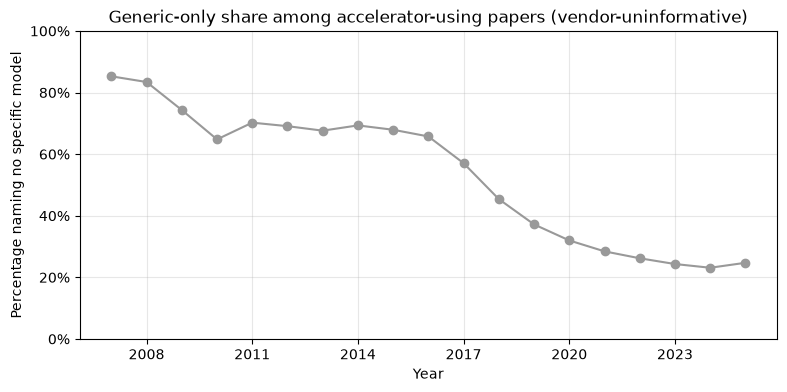

shape: (19, 3)
┌──────┬───────┬──────────────┐
│ year ┆ n     ┆ generic_only │
│ ---  ┆ ---   ┆ ---          │
│ i64  ┆ u32   ┆ f64          │
╞══════╪═══════╪══════════════╡
│ 2007 ┆ 129   ┆ 0.853        │
│ 2008 ┆ 187   ┆ 0.834        │
│ 2009 ┆ 300   ┆ 0.743        │
│ 2010 ┆ 497   ┆ 0.648        │
│ 2011 ┆ 749   ┆ 0.702        │
│ …    ┆ …     ┆ …            │
│ 2021 ┆ 29554 ┆ 0.284        │
│ 2022 ┆ 33932 ┆ 0.262        │
│ 2023 ┆ 43673 ┆ 0.243        │
│ 2024 ┆ 52243 ┆ 0.231        │
│ 2025 ┆ 46117 ┆ 0.247        │
└──────┴───────┴──────────────┘


In [4]:
acc = (flags.join(den, on='corpusid', how='inner')
       .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX) & pl.col('accel_used')))
gs = (acc.group_by('year').agg(n=pl.len(),
                               generic_only=pl.col('generic_only').mean())
      .filter(pl.col('n') >= MIN_PAPERS).sort('year'))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gs['year'], 100 * gs['generic_only'], marker='o', color='#999999')
ax.set(xlabel='Year', ylabel='Percentage naming no specific model', ylim=(0, 100),
       title='Generic-only share among accelerator-using papers (vendor-uninformative)')
ax.grid(alpha=0.3); plt.show()
print(gs.with_columns(pl.col('generic_only').round(3)))

## 8.1 Manufacturer share over time

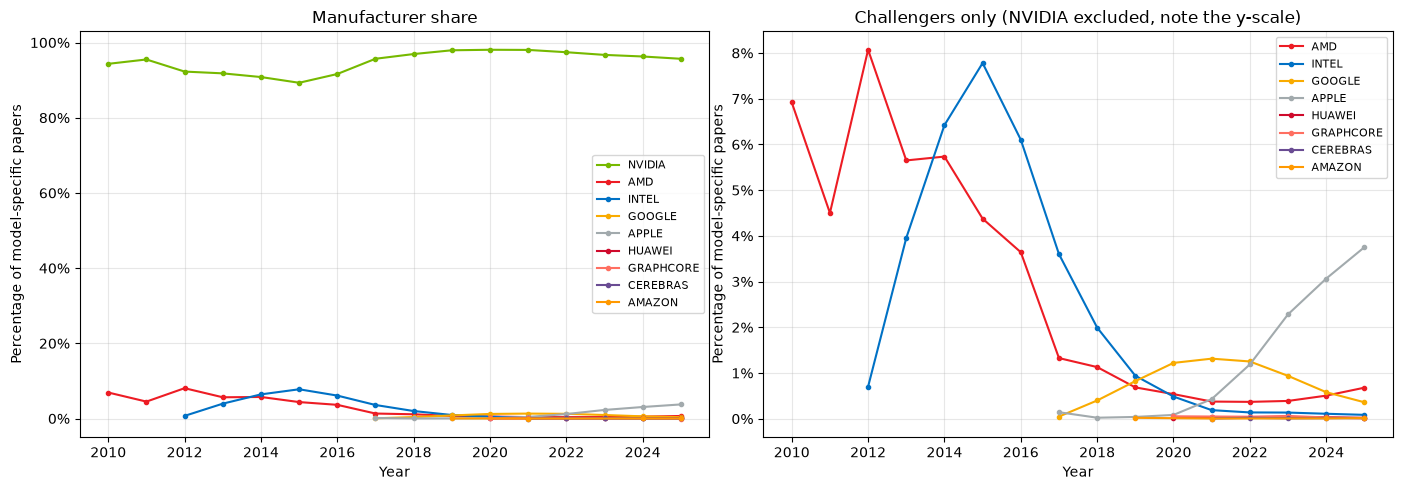

shape: (16, 10)
┌──────┬────────┬────────┬────────┬───┬────────┬───────────┬──────────┬────────┐
│ year ┆ nvidia ┆ amd    ┆ intel  ┆ … ┆ huawei ┆ graphcore ┆ cerebras ┆ amazon │
│ ---  ┆ ---    ┆ ---    ┆ ---    ┆   ┆ ---    ┆ ---       ┆ ---      ┆ ---    │
│ i64  ┆ f64    ┆ f64    ┆ f64    ┆   ┆ f64    ┆ f64       ┆ f64      ┆ f64    │
╞══════╪════════╪════════╪════════╪═══╪════════╪═══════════╪══════════╪════════╡
│ 2010 ┆ 0.9434 ┆ 0.0692 ┆ null   ┆ … ┆ null   ┆ null      ┆ null     ┆ null   │
│ 2011 ┆ 0.955  ┆ 0.045  ┆ null   ┆ … ┆ null   ┆ null      ┆ null     ┆ null   │
│ 2012 ┆ 0.9228 ┆ 0.0807 ┆ 0.007  ┆ … ┆ null   ┆ null      ┆ null     ┆ null   │
│ 2013 ┆ 0.9181 ┆ 0.0565 ┆ 0.0395 ┆ … ┆ null   ┆ null      ┆ null     ┆ null   │
│ 2014 ┆ 0.9083 ┆ 0.0573 ┆ 0.0642 ┆ … ┆ null   ┆ null      ┆ null     ┆ null   │
│ 2015 ┆ 0.893  ┆ 0.0438 ┆ 0.0778 ┆ … ┆ null   ┆ null      ┆ null     ┆ null   │
│ 2016 ┆ 0.9163 ┆ 0.0364 ┆ 0.061  ┆ … ┆ null   ┆ null      ┆ null     ┆ null   │
│ 2017 ┆ 0.9

In [5]:
tot = spec.group_by('year').agg(n=pl.col('corpusid').n_unique())
vs = (spec.group_by('year', 'vendor').agg(k=pl.col('corpusid').n_unique())
      .join(tot, on='year').with_columns(share=pl.col('k') / pl.col('n'))
      .filter(pl.col('n') >= MIN_PAPERS).sort('year'))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for v in VENDORS:
    s = vs.filter(pl.col('vendor') == v)
    if s.height > 2:
        axes[0].plot(s['year'], 100 * s['share'], marker='o', ms=3, label=v.upper(), color=VC[v])
axes[0].set(xlabel='Year', ylabel='Percentage of model-specific papers', title='Manufacturer share')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
non = vs.filter(pl.col('vendor') != 'nvidia')
for v in [x for x in VENDORS if x != 'nvidia']:
    s = non.filter(pl.col('vendor') == v)
    if s.height > 2:
        axes[1].plot(s['year'], 100 * s['share'], marker='o', ms=3, label=v.upper(), color=VC[v])
axes[1].set(xlabel='Year', ylabel='Percentage of model-specific papers',
            title='Challengers only (NVIDIA excluded, note the y-scale)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
with pl.Config(tbl_rows=25):
    print(vs.pivot(on='vendor', index='year', values='share').sort('year')
          .select(['year'] + [c for c in VENDORS if c in vs['vendor'].unique().to_list()])
          .with_columns(pl.exclude('year').round(4)))

## 8.2 Concentration indices

HHI over manufacturer shares (1 = single vendor) and normalized Shannon entropy
(1 = perfectly even). Computed on paper-level vendor shares within each year.

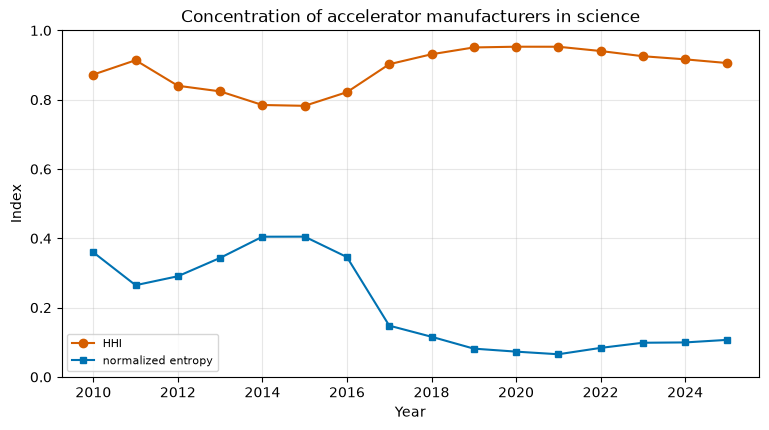

shape: (16, 4)
┌──────┬───────┬─────────┬───────────┐
│ year ┆ hhi   ┆ entropy ┆ n_vendors │
│ ---  ┆ ---   ┆ ---     ┆ ---       │
│ i64  ┆ f64   ┆ f64     ┆ i64       │
╞══════╪═══════╪═════════╪═══════════╡
│ 2010 ┆ 0.873 ┆ 0.36    ┆ 2         │
│ 2011 ┆ 0.914 ┆ 0.265   ┆ 2         │
│ 2012 ┆ 0.84  ┆ 0.291   ┆ 3         │
│ 2013 ┆ 0.824 ┆ 0.344   ┆ 3         │
│ 2014 ┆ 0.785 ┆ 0.405   ┆ 3         │
│ …    ┆ …     ┆ …       ┆ …         │
│ 2021 ┆ 0.953 ┆ 0.065   ┆ 9         │
│ 2022 ┆ 0.941 ┆ 0.084   ┆ 8         │
│ 2023 ┆ 0.926 ┆ 0.099   ┆ 8         │
│ 2024 ┆ 0.917 ┆ 0.1     ┆ 9         │
│ 2025 ┆ 0.906 ┆ 0.107   ┆ 9         │
└──────┴───────┴─────────┴───────────┘


In [6]:
rows = []
for y in sorted(vs['year'].unique().to_list()):
    s = vs.filter(pl.col('year') == y)['share'].to_numpy().astype(float)
    s = s / s.sum()
    ent = -(s * np.log(s)).sum() / np.log(len(s)) if len(s) > 1 else 0.0
    rows.append({'year': y, 'hhi': float((s ** 2).sum()), 'entropy': float(ent),
                 'n_vendors': len(s)})
conc = pl.DataFrame(rows).sort('year')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(conc['year'], conc['hhi'], marker='o', color='#D55E00', label='HHI')
ax.plot(conc['year'], conc['entropy'], marker='s', ms=4, color='#0072B2',
        label='normalized entropy')
ax.set(xlabel='Year', ylabel='Index', ylim=(0, 1),
       title='Concentration of accelerator manufacturers in science')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()
print(conc.with_columns(pl.col('hhi').round(3), pl.col('entropy').round(3)))

## 8.3 CUDA lock-in proxy

Share of accelerator-using papers whose candidate passages mention CUDA versus
the portable stacks. Uses the registry's generic entries (`generic-cuda`,
`generic-opencl`) plus a direct pattern sweep for ROCm/HIP/SYCL/oneAPI/Metal,
run over the stored candidate passages — no LLM required.

In [7]:
import re
from accelscan.s3 import list_keys, make_s3_client
import io
client = make_s3_client()
PAT = {
    'cuda': re.compile(r'(?<!\w)(?:CUDA|cuDNN|cuBLAS|nvcc)(?!\w)'),
    'opencl': re.compile(r'(?<!\w)OpenCL(?!\w)', re.IGNORECASE),
    'rocm_hip': re.compile(r'(?<!\w)(?:ROCm|HIP)(?!\w)'),
    'sycl_oneapi': re.compile(r'(?<!\w)(?:SYCL|oneAPI|DPC\+\+)(?!\w)', re.IGNORECASE),
    'metal_mps': re.compile(r'(?<!\w)(?:Metal Performance Shaders|MPS backend)(?!\w)',
                            re.IGNORECASE),
}
prefix = f'{OUT_PREFIX}/candidates/'
keys = list_keys(prefix, suffix='.parquet', client=client)
cver = sorted({k[len(prefix):].split('/')[0] for k in keys},
              key=lambda v: [int(x) for x in v.split('.')])[-1]
keys = [k for k in keys if k.startswith(f'{prefix}{cver}/')]
print(f'scanning {len(keys)} candidate shards (v{cver})')

acc_ids = set(acc['corpusid'].to_list())
hits = {k: set() for k in PAT}
seen = set()
for i, k in enumerate(keys):
    body = client.get_object(Bucket=BUCKET, Key=k)['Body'].read()
    df = pl.read_parquet(io.BytesIO(body), columns=['corpusid', 'passage_text'])
    for cid, txt in zip(df['corpusid'].to_list(), df['passage_text'].to_list()):
        if cid not in acc_ids:
            continue
        seen.add(cid)
        if not txt:
            continue
        for name, rx in PAT.items():
            if cid not in hits[name] and rx.search(txt):
                hits[name].add(cid)
    if (i + 1) % 50 == 0 or i + 1 == len(keys):
        print(f'  {i+1}/{len(keys)}')
stack = pl.DataFrame({'corpusid': sorted(seen)}).with_columns(
    **{f'sw_{n}': pl.col('corpusid').is_in(sorted(hits[n])) for n in PAT})
print({n: len(v) for n, v in hits.items()}, '| papers scanned:', len(seen))

scanning 214 candidate shards (v0.1.0)
  50/214
  100/214
  150/214
  200/214
  214/214
{'cuda': 24221, 'opencl': 2019, 'rocm_hip': 523, 'sycl_oneapi': 320, 'metal_mps': 50} | papers scanned: 258312


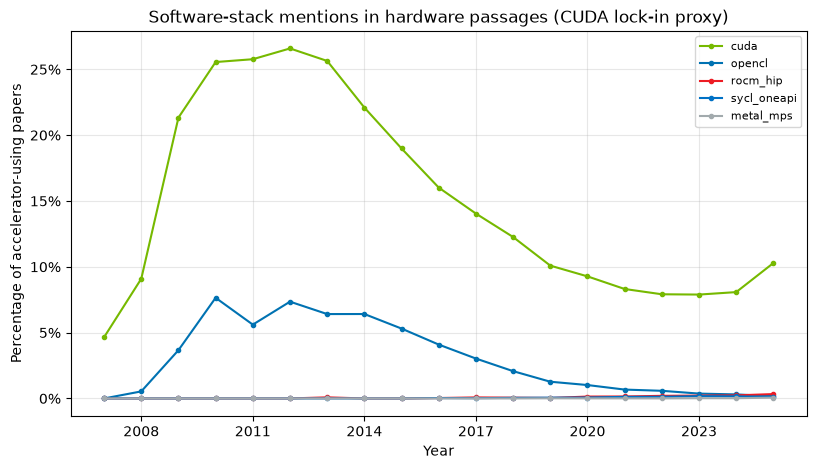

shape: (19, 7)
┌──────┬───────┬────────┬────────┬──────────┬─────────────┬───────────┐
│ year ┆ n     ┆ cuda   ┆ opencl ┆ rocm_hip ┆ sycl_oneapi ┆ metal_mps │
│ ---  ┆ ---   ┆ ---    ┆ ---    ┆ ---      ┆ ---         ┆ ---       │
│ i64  ┆ u32   ┆ f64    ┆ f64    ┆ f64      ┆ f64         ┆ f64       │
╞══════╪═══════╪════════╪════════╪══════════╪═════════════╪═══════════╡
│ 2007 ┆ 129   ┆ 0.0465 ┆ 0.0    ┆ 0.0      ┆ 0.0         ┆ 0.0       │
│ 2008 ┆ 187   ┆ 0.0909 ┆ 0.0053 ┆ 0.0      ┆ 0.0         ┆ 0.0       │
│ 2009 ┆ 300   ┆ 0.2133 ┆ 0.0367 ┆ 0.0      ┆ 0.0         ┆ 0.0       │
│ 2010 ┆ 497   ┆ 0.2555 ┆ 0.0765 ┆ 0.0      ┆ 0.0         ┆ 0.0       │
│ 2011 ┆ 749   ┆ 0.2577 ┆ 0.0561 ┆ 0.0      ┆ 0.0         ┆ 0.0       │
│ 2012 ┆ 993   ┆ 0.2659 ┆ 0.0735 ┆ 0.0      ┆ 0.0         ┆ 0.0       │
│ 2013 ┆ 1217  ┆ 0.2564 ┆ 0.0641 ┆ 0.0008   ┆ 0.0         ┆ 0.0       │
│ 2014 ┆ 1575  ┆ 0.221  ┆ 0.0641 ┆ 0.0      ┆ 0.0         ┆ 0.0       │
│ 2015 ┆ 2054  ┆ 0.1899 ┆ 0.0531 ┆ 0.0      ┆ 0.0

In [8]:
sw = (stack.join(den, on='corpusid', how='inner')
      .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX)))
sy = (sw.group_by('year').agg(n=pl.len(),
                              **{n: pl.col(f'sw_{n}').mean() for n in PAT})
      .filter(pl.col('n') >= MIN_PAPERS).sort('year'))
fig, ax = plt.subplots(figsize=(9.5, 5))
for n, c in zip(PAT, ['#76B900', '#0072B2', '#ED1C24', '#0071C5', '#A2AAAD']):
    ax.plot(sy['year'], 100 * sy[n], marker='o', ms=3, label=n, color=c)
ax.set(xlabel='Year', ylabel='Percentage of accelerator-using papers',
       title='Software-stack mentions in hardware passages (CUDA lock-in proxy)')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()
with pl.Config(tbl_rows=20):
    print(sy.with_columns(pl.exclude('year', 'n').round(4)))
print('\nCUDA : portable-stack ratio, recent years:')
print(sy.with_columns(portable=pl.col('opencl') + pl.col('rocm_hip') + pl.col('sycl_oneapi'))
      .with_columns(ratio=(pl.col('cuda') / pl.col('portable')).round(2))
      .select('year', 'cuda', 'portable', 'ratio').tail(8))

## 8.4 Multi-vendor papers

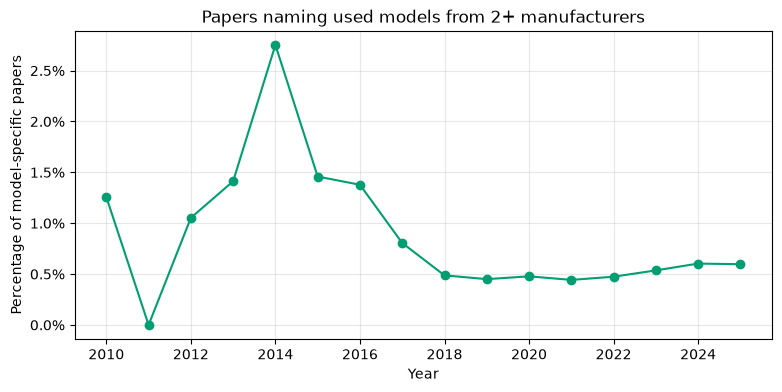

shape: (16, 3)
┌──────┬───────┬────────┐
│ year ┆ n     ┆ multi  │
│ ---  ┆ ---   ┆ ---    │
│ i64  ┆ u32   ┆ f64    │
╞══════╪═══════╪════════╡
│ 2010 ┆ 159   ┆ 0.0126 │
│ 2011 ┆ 200   ┆ 0.0    │
│ 2012 ┆ 285   ┆ 0.0105 │
│ 2013 ┆ 354   ┆ 0.0141 │
│ 2014 ┆ 436   ┆ 0.0275 │
│ …    ┆ …     ┆ …      │
│ 2021 ┆ 20778 ┆ 0.0044 │
│ 2022 ┆ 24671 ┆ 0.0047 │
│ 2023 ┆ 32638 ┆ 0.0054 │
│ 2024 ┆ 39612 ┆ 0.006  │
│ 2025 ┆ 34177 ┆ 0.006  │
└──────┴───────┴────────┘


In [9]:
mv = (spec.group_by('corpusid', 'year').agg(vendors=pl.col('vendor').n_unique())
      .group_by('year').agg(n=pl.len(), multi=(pl.col('vendors') >= 2).mean())
      .filter(pl.col('n') >= MIN_PAPERS).sort('year'))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mv['year'], 100 * mv['multi'], marker='o', color='#009E73')
ax.set(xlabel='Year', ylabel='Percentage of model-specific papers',
       title='Papers naming used models from 2+ manufacturers')
ax.grid(alpha=0.3); plt.show()
print(mv.with_columns(pl.col('multi').round(4)))

## 8.5 Export-control sidebar: A800 / H800 / H20

NVIDIA created these parts specifically for the Chinese market in response to
the October 2022 (and tightened October 2023) US export controls. Their
appearance in the literature dates how quickly a trade-policy intervention shows
up at the bench — and they are a clean marker because they exist for no other
reason.

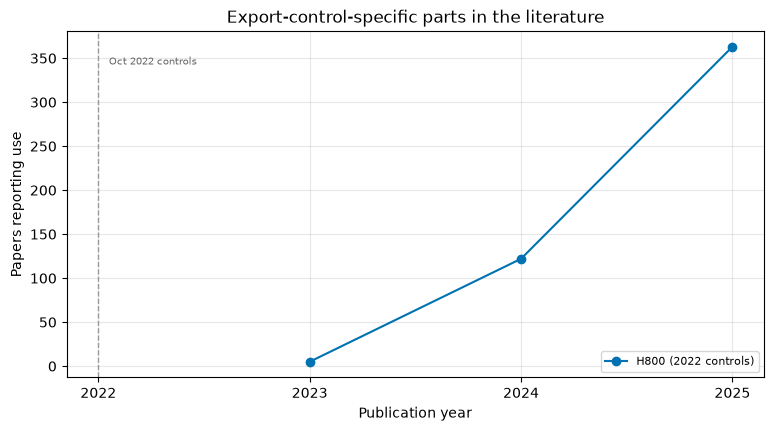

shape: (3, 2)
┌──────┬─────────────┐
│ year ┆ nvidia-h800 │
│ ---  ┆ ---         │
│ i64  ┆ u32         │
╞══════╪═════════════╡
│ 2023 ┆ 5           │
│ 2024 ┆ 122         │
│ 2025 ┆ 363         │
└──────┴─────────────┘


In [10]:
CTRL = {'nvidia-a800': 'A800 (2022 controls)', 'nvidia-h800': 'H800 (2022 controls)',
        'nvidia-h20': 'H20 (2023 controls)'}
ctrl = (spec.filter(pl.col('canonical_model').is_in(list(CTRL)))
        .group_by('canonical_model', 'year').agg(k=pl.col('corpusid').n_unique())
        .sort('year'))
if ctrl.height:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for mid, c in zip(CTRL, ['#D55E00', '#0072B2', '#009E73']):
        s = ctrl.filter(pl.col('canonical_model') == mid)
        if s.height:
            ax.plot(s['year'], s['k'], marker='o', label=CTRL[mid], color=c)
    ax.axvline(2022, color='#999999', ls='--', lw=1)
    ax.text(2022.05, ax.get_ylim()[1] * 0.9, 'Oct 2022 controls', fontsize=7, color='#666666')
    ax.set(xlabel='Publication year', ylabel='Papers reporting use',
           title='Export-control-specific parts in the literature')
    ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()
    print(ctrl.pivot(on='canonical_model', index='year', values='k').sort('year'))
else:
    print('no export-control parts found in used-model mentions')